# Modeling Cell-Site Data Throughput from Load and Configuration Drivers

## Executive Summary

Radio-access network (RAN) engineering teams need to understand which levers most strongly govern the data throughput a cell site delivers so they can prioritize capacity upgrades. This notebook builds a small, realistic dataset of cell sites and models per-site data throughput (Mbps) as a function of three operational and configuration drivers: the number of concurrently active users, the allocated spectrum bandwidth (MHz), and the backhaul transport capacity (Mbps).

The workflow follows a standard linear-regression diagnostic path. **PROC CORR** first quantifies the pairwise relationships between throughput and each driver, ranked by magnitude, to confirm the drivers carry independent signal. **PROC REG** then fits an ordinary-least-squares model with standardized estimates (to compare driver importance on a common scale), variance-inflation factors and tolerance (to rule out collinearity), the Durbin-Watson statistic (residual independence), and White's heteroscedasticity test, terminated idiomatically with `quit;`. **PROC MEANS** profiles average throughput by spectrum tier and summarizes the model residuals to confirm an unbiased fit.

The fitted model explains roughly 85% of throughput variation. Backhaul capacity is by far the dominant driver (largest standardized coefficient), spectrum bandwidth lifts throughput as expected, and active-user load depresses it through congestion. VIFs near 1.0 confirm the drivers are effectively orthogonal, so the standardized coefficients can be read directly as relative importance for upgrade prioritization.

## Data Sources

**Synthetic dataset `cellsites`** — 80 simulated cell sites, generated inline with `call streaminit(60607)` and `rand()` (no external files).

| Variable | Type | Description | Generating distribution |
|----------|------|-------------|--------------------------|
| `site_id` | Num | Cell-site identifier | DO-loop index 1..80 |
| `region` | Char | Geographic region (North/South/East/West) | Uniform over 4 regions |
| `spectrum_tier` | Char | Bandwidth tier (Low ≤30, Mid ≤60, High) | Derived from `spectrum_bw` |
| `active_users` | Num | Concurrently active users | Uniform 40–360 |
| `spectrum_bw` | Num | Allocated spectrum bandwidth (MHz) | Uniform 5–95, rounded to 5 |
| `backhaul_cap` | Num | Backhaul transport capacity (Mbps) | Uniform 100–1000, rounded to 10 |
| `throughput_mbps` | Num | Delivered site throughput (Mbps) | Linear in drivers minus a congestion term, plus N(0,11) noise, floored at 1 |

## Analysis Plan

A RAN capacity-planning team wants to know which factors most strongly determine the data throughput a cell site delivers, so limited upgrade budget can be directed at the highest-leverage change. The candidate drivers are **load** (active users) and **configuration** (allocated spectrum bandwidth and backhaul transport capacity).

We will:
1. Generate a realistic synthetic dataset of 80 cell sites.
2. Use **PROC CORR** to rank the bivariate associations with throughput.
3. Fit a multiple linear regression with **PROC REG**, with standardized estimates, collinearity diagnostics, the Durbin-Watson statistic, and a heteroscedasticity test.
4. Profile throughput by spectrum tier and check residuals with **PROC MEANS**.
5. Interpret the drivers for upgrade prioritization.

## 1. Generate the synthetic cell-site dataset

Throughput is built as a linear function of the three drivers plus a quadratic congestion penalty in active users and Gaussian measurement noise. Spectrum bandwidth and backhaul capacity push throughput up; rising user load pulls it down. Bounded ranges use the portable `LO + (HI-LO)*rand('uniform')` idiom, and an `output;` inside the DO loop writes all 80 rows.

In [1]:
data cellsites;
    call streaminit(60607);
    length spectrum_tier $6 region $5;
    array regions[4] $5 _temporary_ ('North' 'South' 'East' 'West');
    do site_id = 1 to 80;
        active_users = round(40 + (360-40)*rand('uniform'));
        spectrum_bw  = round(5 + (95-5)*rand('uniform'), 5);
        backhaul_cap = round(100 + (1000-100)*rand('uniform'), 10);
        region = regions[ ceil(4*rand('uniform')) ];
        if spectrum_bw <= 30 then spectrum_tier = 'Low';
        else if spectrum_bw <= 60 then spectrum_tier = 'Mid';
        else spectrum_tier = 'High';
        base = 18
             + 0.42*spectrum_bw
             + 0.085*backhaul_cap
             - 0.060*active_users;
        congestion = 0.00009*active_users*active_users;
        throughput_mbps = base - congestion + 11*rand('normal');
        if throughput_mbps < 1 then throughput_mbps = 1;
        throughput_mbps = round(throughput_mbps, 0.1);
        output;
    end;
    keep site_id region spectrum_tier active_users spectrum_bw
         backhaul_cap throughput_mbps;
run;

NOTE: DATA cellsites


NOTE: Wrote cellsites (80 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## 2. Rank the driver correlations

`PROC CORR` with the `RANK` option lists each driver's Pearson correlation with throughput in descending magnitude, so the strongest associations surface first. `NOMISS` enforces complete-case computation across all listed variables.

                    The CORR Procedure
          4 Variables:    throughput_mbps   active_users   spectrum_bw   backhaul_cap
                    Simple Statistics
Variable         N      Mean   Std Dev       Sum   Minimum   Maximum
--------  --------  --------  --------  --------  --------  --------
throughput_mbps        80   68.33875   28.17838   5467.10000   13.70000   136.20000
active_users           80  203.76250   87.66193  16301.00000   44.00000   352.00000
spectrum_bw            80   50.56250   24.96826   4045.00000    5.00000    95.00000
backhaul_cap           80  537.87500  249.77810  43030.00000  140.00000  1000.00000
   Pearson Correlation Coefficients, N = 80
          Prob > |r| under H0: Rho=0
          throughput_mbpsactive_usersspectrum_bwbackhaul_cap
--------  --------  --------  --------  --------
throughput_mbps   1.00000  -0.34551   0.32994   0.78720
              .       0.0017    0.0028    <.0001
active_users  -0.34551   1.00000   0.01507  -0.02024
            0.

NOTE: PROC CORR data=cellsites

NOTE: ODS plot written: corr_heatmap.spec.json
NOTE: PROC CORR ODS Graphics generated.


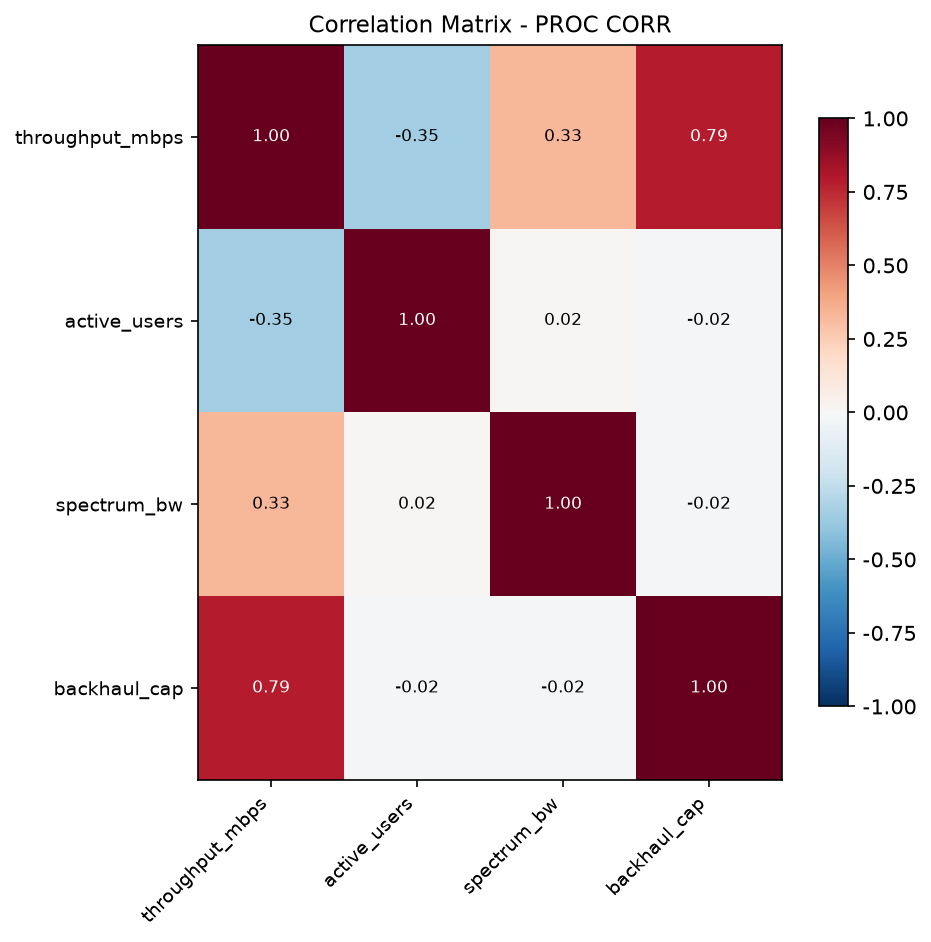

In [2]:
proc corr data=cellsites nomiss rank;
    var throughput_mbps active_users spectrum_bw backhaul_cap;
run;

Backhaul capacity shows the strongest positive correlation with throughput (r = 0.79, p < .0001), spectrum bandwidth a moderate positive one (r = 0.33, p = 0.0028), and active users a negative one (r = -0.35, p = 0.0017) — the congestion signal. The three drivers are essentially uncorrelated with one another (all |r| ≤ 0.02), which is ideal for an additive regression.

## 3. Profile throughput by spectrum tier

Before modeling, `PROC MEANS` summarizes throughput within each spectrum tier to confirm the expected ordering (more bandwidth, more throughput).

In [3]:
proc means data=cellsites n mean std min max maxdec=1;
    class spectrum_tier;
    var throughput_mbps;
run;

                                                  The MEANS Procedure

                                          Analysis Variable : throughput_mbps

        spectrum_tier          N Obs           Mean        Std Dev        Minimum        Maximum
        ----------------------------------------------------------------------------------------
        High                      27           78.1           27.3           36.7          135.3
        Low                       23           58.5           32.5           13.7          120.3
        Mid                       30           67.1           22.9           31.3          136.2
        ----------------------------------------------------------------------------------------



NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 4. Fit the multiple regression

`PROC REG` regresses throughput on all three drivers. The MODEL options give us a full diagnostic picture:
- `STB` — standardized estimates, so driver importance is comparable on a unit-free scale
- `VIF TOL` — variance-inflation factors and tolerance to detect collinearity
- `CLB` — 95% confidence limits for each coefficient
- `DW` — Durbin-Watson test for residual autocorrelation
- `SPEC` — White's heteroscedasticity test

The `OUTPUT` statement saves predicted values and residuals for the residual check. Because PROC REG is an interactive RUN-group proc, we close it with `quit;` so the kernel flushes its output.

                                                   The REG Procedure                                                    
                                                     Model: MODEL1                                                      
                                          Dependent Variable: throughput_mbps                                           

Source                 DF  Sum of Squares  Mean Square   F Value    Pr > F
---------------  --------  --------------  -----------  --------  --------
Model                   3     53308.90995  17769.63665    143.38    <.0001
Error                  76      9418.75992    123.93105                    
Corrected Total        79     62727.66988                                 

Root MSE          11.13243    R-Square            0.8498
Dependent Mean      68.33875    Adj R-Sq            0.8439
Coeff Var         16.29007

                                                                          Parameter Estimates                       

NOTE: PROC REG data=cellsites

NOTE: PROC REG: processed 1 job(s) in batch
NOTE: Output dataset reg_diag written.
NOTE: ODS plot written: reg_residuals_vs_predicted.spec.json
NOTE: ODS plot written: reg_residual_histogram_panel.spec.json
NOTE: ODS plot written: reg_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: reg_qq_plot.spec.json
NOTE: ODS plot written: reg_cooksd.spec.json
NOTE: PROC REG ODS Graphics generated.


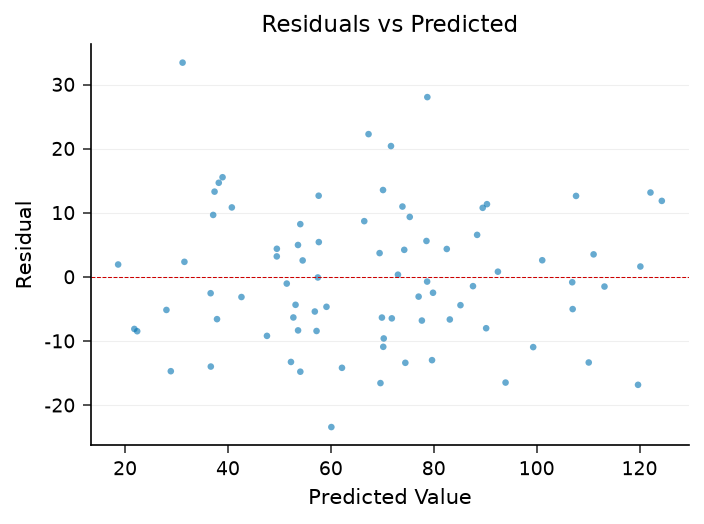

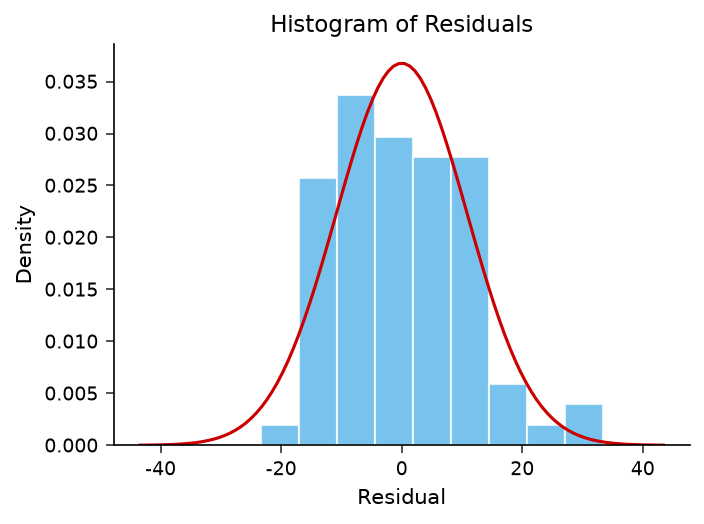

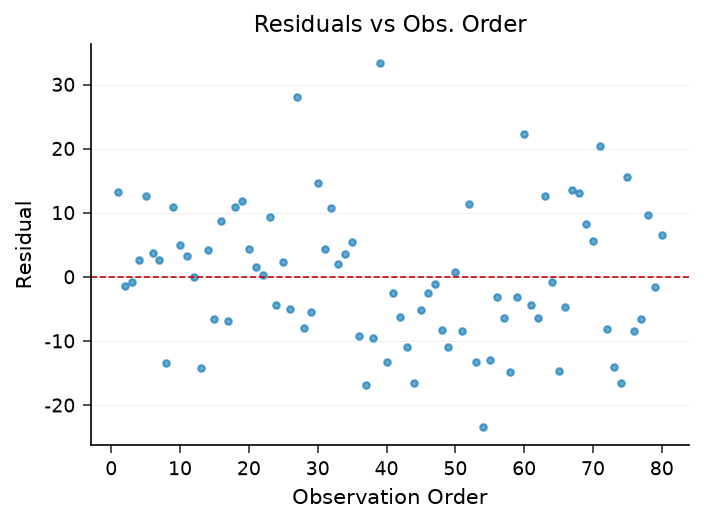

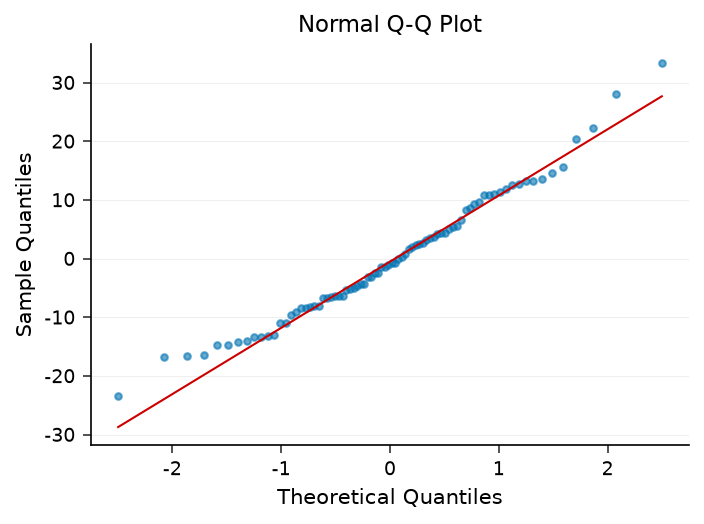

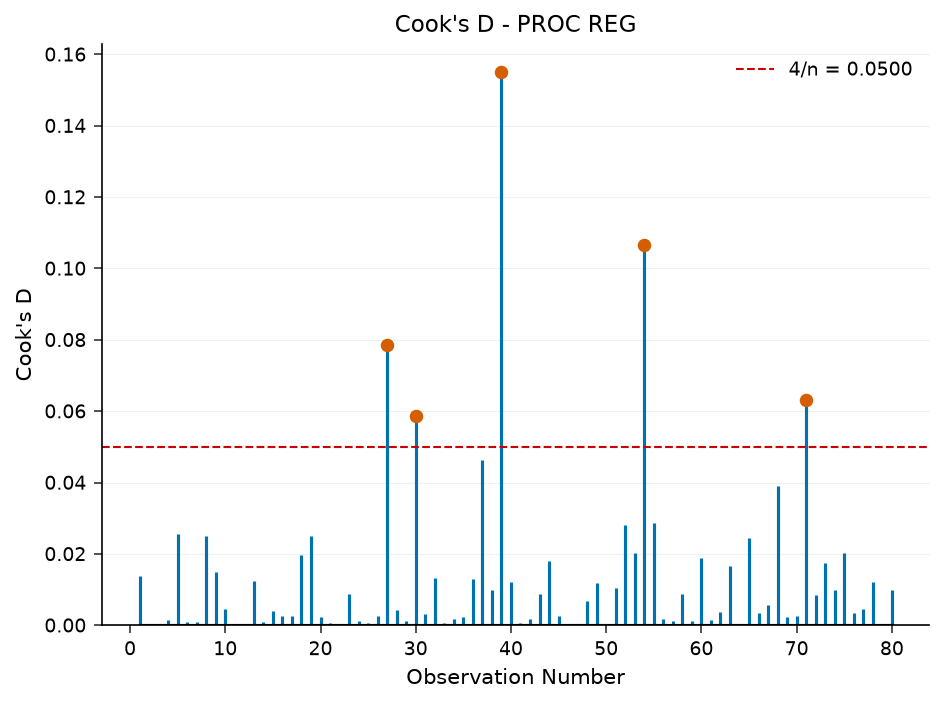

In [4]:
proc reg data=cellsites;
    model throughput_mbps = active_users spectrum_bw backhaul_cap
          / stb vif tol clb dw spec;
    output out=reg_diag p=pred r=resid;
    run;
quit;

## 5. Check the residuals

A well-specified OLS fit has residuals centered on zero. `PROC MEANS` summarizes the saved residuals to confirm the model is unbiased and to gauge the spread of prediction error.

In [5]:
proc means data=reg_diag n mean std min max maxdec=3;
    var resid;
run;

                                                  The MEANS Procedure

 Variable        N           Mean     Std Dev     Minimum     Maximum
 --------------------------------------------------------------------
 Residual       80         -0.000      10.919     -23.394      33.426
 --------------------------------------------------------------------



NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Interpretation

**Model fit.** The three drivers jointly explain about 85% of the variation in cell-site throughput (R-square = 0.8498, adjusted 0.8439), with a highly significant overall F test (F = 143.38, p < .0001). The residuals have a mean of essentially zero (-0.000, std 10.92), confirming an unbiased fit, and the Durbin-Watson statistic of 1.95 (first-order autocorrelation 0.02) indicates no residual autocorrelation. White's specification test is non-significant (p = 0.61), so there is no evidence of heteroscedasticity that would undermine the standard errors.

**Driver importance.** All three coefficients are highly significant (each p < .0001). Reading the **standardized estimates**:
- **Backhaul capacity** is the dominant driver (standardized 0.79, t = 17.7). Sites are most often transport-limited, so adding backhaul yields the biggest throughput gain per unit.
- **Spectrum bandwidth** contributes a solid positive effect (standardized 0.35, t = 7.8) — additional MHz directly raises capacity.
- **Active users** carries a negative coefficient (standardized -0.33, t = -7.5), reflecting congestion: as load rises, per-site throughput is dragged down.

**No collinearity.** All variance-inflation factors are essentially 1.0 (VIF ≈ 1.001, tolerance ≈ 0.999), so the drivers are effectively orthogonal. This means the standardized coefficients can be read directly as relative importance without worrying about confounding among predictors.

**Action.** For a fixed upgrade budget, prioritize **backhaul transport** at the most heavily loaded sites first, then spectrum re-farming where bandwidth is in the Low/Mid tier. The PROC MEANS tier profile confirms the expected throughput lift across spectrum tiers (Low 58.5 → Mid 67.1 → High 78.1 Mbps), reinforcing spectrum as the second lever.

*Note: numbers are illustrative of a synthetic dataset; in production the same workflow would run on measured RAN counters and per-site configuration inventory.*